# Abstract

Here we investigate the expected ability of a new remote-sensing stand-off infrared spectrometer, *Enfys*, for the ExoMars Rosalind Franklin Rover, to resolve diagnostic features of the reflectance spectra of key minerals previously identified on the surface of Mars.

In this notebook we simulate Enfys performance using an InAs sensor, that is subject to thermal noise from the Enfys structure.

# Introduction

As discussed in [previous notebooks](./Simulating%20Spectral%20Sampling%20of%20the%20MICA%20Files%20with%20the%20Enfys%20IR%20Spectrometer%20for%20the%20ExoMars%20Rosalind%20Franklin%20Rover.ipynb), Enfys is an Infra-Red point-spectrometer for the ExoMars Rosalind Franklin rover.

In these notebooks we explore how we expect Enfys to sample minerals of interest on the Mars surface.

In this notebook, we consider the expected performance of Enfys using an InAs Mid-Wave Infrared sensor for the wavelength range of 1.6 - 3.1 µm.

Included in the modelling is the noise expected for the sensor, as provided by the EXM-EN-MTX-ABU-0001_Enfys_Science_Traceability_Matrix_3-0 document.


## Problem
This optical design is functionally different to the Acousto-Optic Tunable Filter design of ISEM, so it is important that the design is demonstrated to fulfil the performance requirements of the instrument, and that expectations of performance can be set prior to laboratory tests of the completed instrument.

At time of writing, the spectrometer is in the development stage. This notebook describes how the Spectral Parameters Toolkit[^stabbins2024] can be used to convert the developing expectations of the spectral range and resolution and radiometric sensitivity of the instrument into predictions of its ability to discriminate mineral species and phases on the Mars surface at the rover landing site.

[^stabbins2024]: Stabbins, R., & Grindrod, P. (2024). The Spectral Parameters Toolkit (sptk): Release v0.1 (Version v0.1) [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.10694286


# Method

To investigate the expected performance we use high-resolution laboratory measured spectra of a range of minerals expected at the Mars surface, and computationally simulate the sampling of the spectra with the expected spectral response of *Enfys*. We will perform repeat sampling with synthetically added noise to investigate the spectral and radiometric limits of the instrument.

We will produce a number of visualisations to investigate the predicted instrument performance, and demonstrate the limits of the instrument discriminatory ability.

## Spectral Resampling
We take a simple approach to resampling, as follows. 

We neglect reflectance calibration uncertainty, and any systematic uncertainty when merging the data from the two separate photodiodes, and assume that the linear-variable filter movement is perfectly calibrated such that a measurement at centre-wavelength $\lambda_{cwl}$ can be requested with arbitrary precision.

We assume an observation of $\lambda_{cwl}$ has a Cauchy transmission profile, and, prior to component characterisation, a spectral resolving power of $\lambda/\Delta\lambda=100$ is achieved for all $\lambda_{cwl}$, such that the Cauchy transmission profile for $\lambda_{cwl}$ has a full-width-at-half-maximum of $\Delta\lambda = \lambda_{cwl}/100$.

The Cauchy transmission profile $T(\lambda|\lambda_{cwl})$ is given by

$$
T(\lambda|\lambda_{cwl}) = \frac{\gamma^2}{(\lambda - \lambda_{cwl}^2) + \gamma^2}
$$

where $\gamma = \Delta\lambda/2 = (\lambda_{cwl}/100)/2$.

We assume that a high-resolution laboratory spectrum approximates the continuous function $R(\lambda)$, such that the calibrated reflectance at $\lambda_{cwl}$ has the expected value $R[\lambda_{cwl}]$ of:

$$
R[\lambda_{cwl}] = \frac{\int R(\lambda)T(\lambda|\lambda_{cwl}) d\lambda }{\int T(\lambda|\lambda_{cwl}) d\lambda}
$$

To simulate noise we add $\varepsilon$, an additive noise term that we draw from the Gaussian distribution with variance:

$$
\sigma^2 = \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}}
$$

under the assumption that maximum $\text{SNR}$ is only achieved for $R = 1$, and the noise is dominated by counting noise, such that $\sigma$ follows a Poissonian relationship with the signal $R$.

For each observation $R[\lambda_{cwl}]$ we draw 100 repeat samples, such that

$$
R_i[\lambda_{cwl}] = R[\lambda_{cwl}] + \varepsilon_i
$$

with 

$$
\varepsilon_i \sim \mathcal{N}\left(0, \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}}\right)
$$

This gives an indication of the expected noise of a calibrated *Enfys* acquired spectrum.

## Analysis

For now, we simply produce plots of the resampled spectra, and visually inspect the plots to consider the ability to resolve diagnostic spectral features against the noise. We will include more details of analysis as that is developed here.

## Notebook and Environment Setup

Here we include the required code blocks for setting up this notebook for this study.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `sudo ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

We will be using the Spectral Parameters Toolkit. First we import the required modules.

In [2]:
import sptk.config as cfg
from sptk.material_collection import MaterialCollection
from sptk.instrument import Instrument
from sptk.observation import Observation
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

We set our simulation resolution range to extend the range of Enfys, of 0.9 - 3.1 µm, such that the long tails of the Cauchy distribution of the linear-variable-filter profiles can be accommodated during sampling. We leave our spectral resolution at 1 nm for all $\lambda$.

In [3]:
cfg.update_sample_res('wvl_min', 380)
cfg.update_sample_res('wvl_max', 3300)

Finally we set the project name.

In [4]:
PROJECT_NAME = 'enfys_mica_inas_mwir'

# Data

For this study we are using a spectral library of minerals identified through CRISM analysis ([the MICA files](http://crism.jhuapl.edu/data/mica/))[^viviano-beck2014]. Here we use the laboratory spectra that have been identified that best represent the type localities presented in the MICA files. These can be accessed [here](https://crismtypespectra.rsl.wustl.edu/), and are sourced from the RELAB and USGS public spectral libraries.

[^viviano-beck2014]: Viviano-Beck, C. E., Seelos, F. P., Murchie, S. L., Kahn, E. G., Seelos, K. D., Taylor, H. W., Taylor, K., Ehlmann, B. L., Wiseman, S. M., Mustard, J. F., & Morgan, M. F. (2014). Revised CRISM spectral parameters and summary products based on the currently detected mineral diversity on Mars. Journal of Geophysical Research: Planets, 119(6), 1403–1431. https://doi.org/10.1002/2014JE004627


We have grouped the spectral library into categories as follows, and included this categorisation in the sptk distribution, accessed from the ```sptk.material_sets``` module.

In [5]:
from sptk.material_sets import MICA_SET

We use the ```sptk.material_collection``` module to parse the spectral library:

In [6]:
matcol = MaterialCollection(
        MICA_SET,
        'MICA_new_dirtree', 
        PROJECT_NAME, 
        load_existing=False,
        balance_classes=False,
        random_bias_seed=None,
        allow_out_of_bounds=True,
        plot_profiles=False,
        export_df=True)

Building new enfys_mica_inas_mwir MaterialCollection DF

---------------------------------
Category
└──species|subgroup|group|
   └──data_id status
---------------------------------
Iron Oxides & Primary Silicates
└──-clinopyroxene|pyroxenes|inosilicates|
   └──-NBPP22.csv loaded
└──-orthopyroxene|pyroxenes|inosilicates|
   └──-LAPP47B.csv loaded
└──-fayalite|olivines|nesosilicates|
   └──-LAPO05.csv loaded
└──-forsterite|olivines|nesosilicates|
   └──-LASC02.csv loaded
└──-hematite|hematites|oxides|
   └──-GDS27.csv loaded
└──-plagioclase|feldspars|tectosilicates|
   └──-NCLS04.csv loaded
---------------------------------
Sulfates
└──-alunite|hydrous_sulphates|sulphates|
   └──-F1CC08B.csv loaded
└──-bassanite|hydrous_sulphates|sulphates|
   └──-GDS145.csv loaded
└──-gypsum|hydrous_sulphates|sulphates|
   └──-LASF41A.csv loaded
└──-jarosite|hydrous_sulphates|sulphates|
   └──-LASF21A.csv loaded
└──-kieserite|hydrous_sulphates|sulphates|
   └──-F1CC15.csv loaded
└──-mg-sulphate|hydrous

We can use the ```material_collection``` plotting routines to visualise the library.

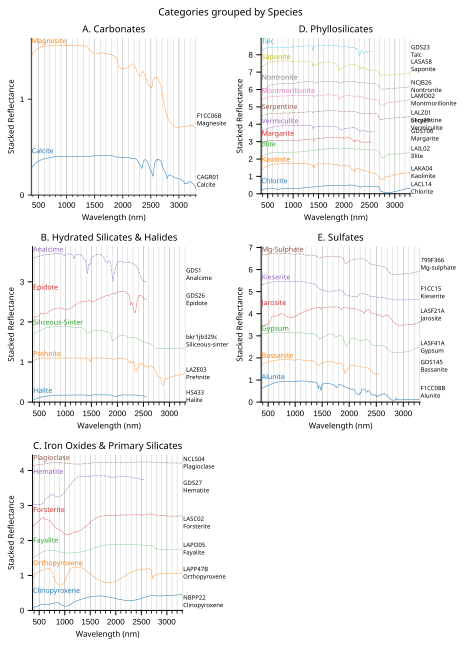

In [7]:
ax = matcol.plot_profiles(stacked=True, scope='categories', groupby='Species')

**Figure 2** High resolution MICA Files spectral library, arranged by category and grouped by mineral species.

We can see that not all of the entries cover the complete 0.9 - 3.1 µm range of *Enfys*, so in future work we should look to replace these MICA files laboratory type spectra with spectra that all span the entire range.

We can also produce a waterfall visualisation, an alternative plotting method that presents the information in a condensed format, that is useful for highlighting where absorption features lie.

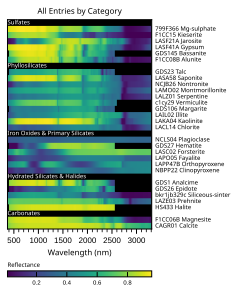

In [8]:
axes = matcol.plot_profiles(waterfall=True, scope='all', groupby='Category')

**Figure 3** Waterfall plot of the high resolution MICA Files spectral library, arranged by category and grouped by mineral species.

A more useful version of this plot format is to show band locations after continuum removal. We can use the `SpectralLibraryAnalyser.remove_continuum()` function to produce a duplicate of the `MaterialCollection` but with the data continuum-removed.

In [9]:
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

matcol_sla = sla(matcol)
matcol_cr = matcol_sla.remove_continuum()

We can plot the profiles to illustrate the continuum removal. Here we use the `scope = 'all'` version of the profile plot.

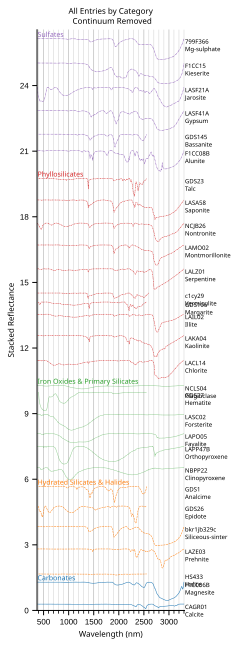

In [10]:
axes = matcol_cr.plot_profiles(stacked=True, scope='all', groupby='Category')

**Figure 4** Continuum-removed high resolution MICA Files spectral library, grouped by Category.

Now we plot the waterfall representation:

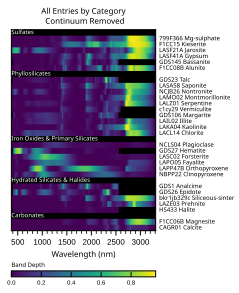

In [11]:
axes = matcol_cr.plot_profiles(waterfall=True, scope='all', groupby='Category')

**Figure 5** Continuum-removed waterfall plot of high resolution MICA Files spectral library, grouped by Category.

Again, we can see that the waterfall plot represents the band depth information of the `MaterialCollection` in a compact format. Scanning vertically allows for quick identification of common band locations, their depths, widths, and asymmetries.

# Results

## Simulating the Enfys Spectral Response

To simulate Enfys, rather than providing a file with the expected spectral response of each position of the Linear-Variable Filter (LVF, above), we specify the spectral range and resolution and sampling regime, and generate a set of central-wavelengths and bandwidths. We do this with the ```InstrumentBuilder``` class of the ```sptk.instrument``` module.

In [12]:
from sptk.instrument import InstrumentBuilder

The expected spectral resolution of Enfys is $\lambda/\Delta\lambda = 100$, and the range when using the InGa sensor is 0.9 - 3.1 µm.

### Signal-to-Noise Ratio

We obtain the expected SNR from the enfys_inas_mwir_snr.csv file, derived from the EXM-EN-MTX-ABU-0001_Enfys_Science_Traceability_Matrix_3-0 spreadsheet.

We have adapted the InstrumentBuilder function to accept a pandas Series mapping wavelength to SNR. The InstrumentBuilder then performs interpolation to the simulated wavelength range.

We read in the SNR file:

In [13]:
import pandas as pd

enfys_snr = pd.read_csv('../data/instruments/enfys_snr.csv', index_col=0)

and get the SNR data for the InAs MWIR sensor,

In [14]:
inas_mwir_snr = enfys_snr['InAs MWIR SNR']

and the InGaAs SWIR sensor,

In [15]:
ingaas_swir_snr = enfys_snr['InGaAs SWIR SNR']

and then we splice these together, using the higher value SNR where the wavelength ranges overlap:

<AxesSubplot: xlabel='Wavelength(um)'>

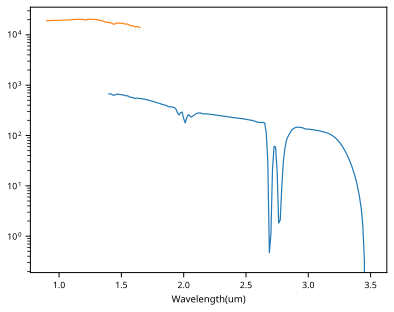

In [16]:
inas_mwir_snr.plot(logy=True)
ingaas_swir_snr.plot()

In [17]:
# concatanate the inas_mwir_snr and the ingaas_swir, using the highest SNR for overlapping wavelength values
enfys_inas_mwir_snr = ingaas_swir_snr.combine_first(inas_mwir_snr)

We also convert the wavelengths from µm to nm:

In [18]:
enfys_inas_mwir_snr.index = enfys_inas_mwir_snr.index * 1000

for computational convenience, we should set values of SNR<=1 to NaN, to interpret these as 'bad bands'

In [19]:
# where SNR <=1 to NaN, to interpret these as 'bad bands'
import numpy as np
enfys_inas_mwir_snr = enfys_inas_mwir_snr.where(enfys_inas_mwir_snr > 30, other=np.nan)

In [20]:
enfys_inas_mwir_snr.index.name = 'wavelength'

Text(0, 0.5, 'SNR')

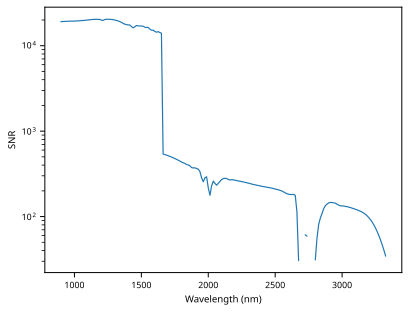

In [21]:
g = enfys_inas_mwir_snr.plot(logy=True)
# set the x and y axes
g.set_xlabel('Wavelength (nm)')
g.set_ylabel('SNR')

### Spectral Resolving Power

We can also load in new data for the spectral resolving power of the SWIR and MWIR channels of Enfys.

This data has been digitsed from the plot reported in the Enfys schedule review 20250807 ppt, by Matt Gunn.

In [22]:
enfys_swir_respow = pd.read_csv('../data/instruments/enfys_swir_respow.csv', index_col=0)
enfys_mwir_respow = pd.read_csv('../data/instruments/enfys_mwir_respow.csv', index_col=0)

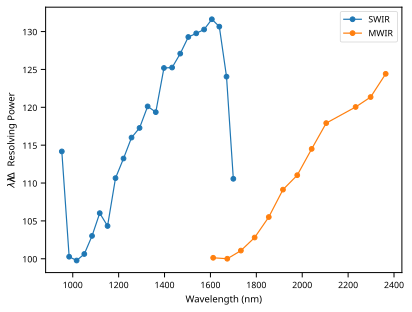

In [23]:
g=enfys_swir_respow.plot(label='SWIR', marker='o')
enfys_mwir_respow.plot(marker='o',label='MWIR', xlabel='Wavelength (nm)', ylabel=r'$\lambda/\Delta\lambda$ Resolving Power',ax=g)
g.legend(['SWIR', 'MWIR'])

We now need to merge these datasets, following the same rule as the SNR merger, i.e. ensuring that the correct channel is used for the overlapping data.

In [24]:
# get the max wavelength where ingaas_swir_snr is not nan
ingaas_swir_snr = ingaas_swir_snr[~np.isnan(ingaas_swir_snr)]
max_swir_wavelength = ingaas_swir_snr.index[-1] * 1000 # convert from µm to nm
max_swir_wavelength

1650.0

In [25]:
# get the enfys_swir_respow data where the wavelength is less than the max_swir_wavelength
enfys_swir_respow = enfys_swir_respow[enfys_swir_respow.index < max_swir_wavelength]
enfys_swir_respow

,Resolving Power
Wavelength,
952.350,114.172
984.300,100.267
1016.886,99.765
1050.340,100.625
1084.064,103.015
1117.569,106.020
1151.685,104.326
1186.342,110.645
1221.214,113.238


In [26]:
# get the enfys_mwir_respow where the wavelength is greater than the max_swir_wavelength
enfys_mwir_respow = enfys_mwir_respow[enfys_mwir_respow.index > max_swir_wavelength]
enfys_mwir_respow

,Resolving Power
Wavelength,
1673.354,100.000
1732.701,101.075
1792.699,102.803
1854.283,105.507
1916.113,109.126
1978.328,111.035
2041.291,114.507
2104.575,117.912
2232.792,120.042


In [27]:
# now merge the datasets
enfys_respow = pd.concat([enfys_swir_respow, enfys_mwir_respow])

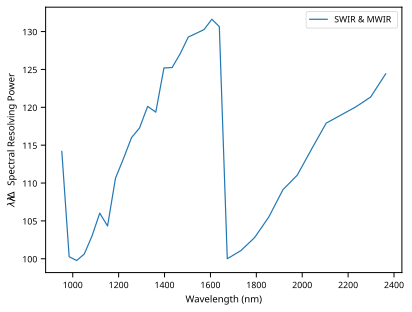

In [28]:
g=enfys_respow.plot(xlabel='Wavelength (nm)', ylabel=r'$\lambda/\Delta\lambda$ Spectral Resolving Power')
g.legend(['SWIR & MWIR'])

We now need to pass this data to the InstrumentBuilder function.

### Instrument Build

Now we will pass this to the InstrumentBuilder:

In [29]:
enfys_builder = InstrumentBuilder(
    instrument_name='enfys_inas_mwir',
    instrument_type='lvf',
    sampling='nyquist',
    resolution = enfys_respow,
    spectral_range=[900, 3101],
    snr = enfys_inas_mwir_snr)

Exporting instrument to ../data/instruments/enfys_inas_mwir.csv...


In [30]:
from sptk.instrument import Instrument

Now we build the transmission profiles for each LVF position, according to the list of CWLs and FWHMs generated above. These are accessed by reading the ```.csv``` file produced by the ```InstrumentBuilder``` procedure.

When generating the profiles, we turn the CWL and FWHM into a profile by assuming a distribution function. For Enfys we use the Cauchy distribution, which behaves similarly to a Gaussian, but with wider 'wings'. It is parameterised by the full-width-at-half-maximum, as the distribution strictly has no finite variance. We have implemented a ```build_cauchy_filter``` method for the ```Instrument``` class.

In [31]:
enfys = Instrument(
            name = 'enfys_inas_mwir', # filename of the instrument information, held in /software/data/instruments/            
            project_name = matcol.project_name, # the project directory name, hosting outputs in the /spectral_parameter_studies/ directory
            shape = 'cauchy',
            load_existing=False, # if True, load existing instrument data from the project directory
            plot_profiles=False, # if true, plot the transmission profiles during construction
            export_df=True) # if True, export the instrument transmission profiles to the project directory

Building Instrument...
Building new DataFrame for 'enfys_inas_mwir'...
Exporting the Instrument to CSV and Pickle formats...


Plotting Instrument Transmission...


/opt/homebrew/Caskroom/miniconda/base/envs/enfys_sptk/lib/python3.10/site-packages/seaborn/_oldcore.py:200: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if palette in QUAL_PALETTES:


Plotting Maximum Signal-to-Noise Ratio...
Plotting FWHM...
Plotting Spectral Resolution...
Plots exported to ../projects/enfys_mica_inas_mwir/instrument


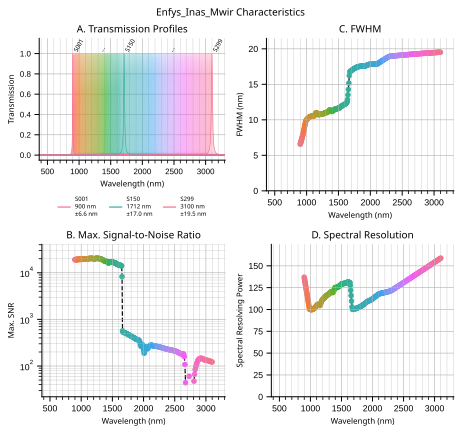

In [32]:
fig ,ax = enfys.plot_instrument_characteristics()

**Figure 6** Simulated spectral response and resolution of *Enfys*, based on preliminary expectations of the spectral and radiometric response.

The data shown in figure 3 approximates the expected performance of *Enfys*. Once the instrument is calibrated at the component and assembled levels, this data can be replaced with empirically aqcuired data.

## Sampling MICA with Enfys

We now make an ```Observation``` object by sampling the MICA files ```MaterialCollection``` with the Enfys ```Instrument```.

In [33]:
from sptk.observation import Observation

In [34]:
obs = Observation(
    material_collection=matcol,
    instrument = enfys,
    load_existing=False,
    plot_profiles=False,
    export_df=True)

Building new Observation DataFrame                                                  for 'enfys_mica_inas_mwir'...
Sampling the Material Collection with the Instrument...
Sampling complete.
Exporting the Observation Pickle format...
Observation export complete.


We can plot the sampled spectra against the input high-spectra below:

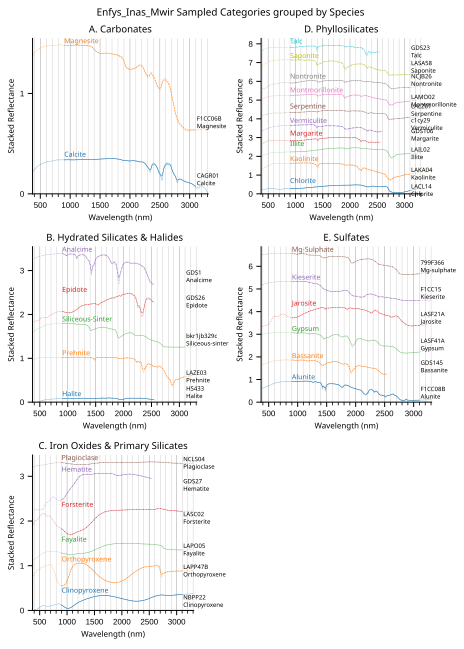

In [35]:
axes = obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=True)

**Figure 7** The MICA files as sampled by *Enfys*, with the original high-resolution spectra plotted underneath each.

We can now see where there are deviations of the *Enfys* sampled spectra from the high-resolution source spectra. 

For example, illite, plotted below for clarity.

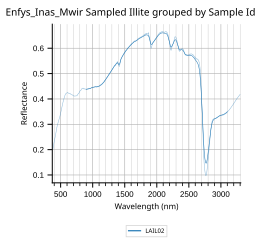

In [36]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True)

**Figure 8** Deviation of the *Enfys* sampled spectrum from the high-resolution input spectrum for Illite.

We note that there is an effect by which peaks and troughs in the spectra are reduced. This is due to the long tails of the Cauchy filter profiles. Despite the reduction of absolute band depth, the features of Illite (fig. 8) are still resolvable.

We can produce a continuum-removed waterfall plot to check that the major bands are resolved.

In [37]:
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

obs_cr = sla(obs).remove_continuum()

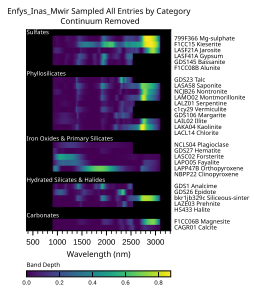

In [38]:
axes = obs_cr.plot_profiles(waterfall=True, scope='all', groupby='Category')

**Figure 9** Continuum-Removed waterfall plot of the MICA files as sampled by *Enfys*.

Comparing Figure 9 to Figure 5, we can see that the weaker sub-2 µm bands are less well resolved.

We can save this data

In [39]:
obs_cr.export_main_df()

Exporting the Observation Pickle format...
Observation export complete.


## Adding Synthetic Noise

We have the capability to add synthetic noise to the dataset, by redrawing a sample from the dataset with noise added according to the signal-to-noise ratio specified for the given channel.

We can optionally redraw multiple noisy samples for each entry, to give an indication of the statistical uncertainty, or for example draw a single noisy sample, to produce a single-observation mission-realistic dataset.

For an entry with reflectance $R[\lambda_{cwl}]$, we redraw a sample:

$\tilde R_i[\lambda_{cwl}] = R[\lambda_{cwl}] + \epsilon_i$

where $\epsilon_i$ is drawn from:

$\epsilon_i \sim \mathcal{N}(0, \sigma[\lambda_{cwl}]^2)$

where $\sigma[\lambda_{cwl}]$ is the noise on the reflectance measurement, given by:

$\sigma[\lambda_{cwl}] = R[\lambda_{cwl}] / \text{SNR}[\lambda_{cwl}]$

First, let's draw a single noisy entry:

In [40]:
noise_obs = obs.add_noise(1, seed=0)

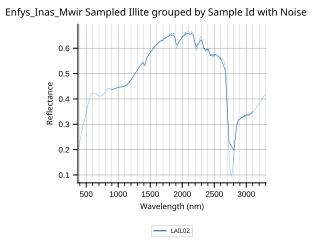

In [41]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True, ci=False)

**Figure 10** Noisy resampled example spectrum for Illite, showing 1 noisy sample according to the spectral signal-to-noise ratio illustrated in figure 3.B.

We can also plot the mean observed line, with shading indicating the standard deviation of the noisy data, shown below in figure 7, where the 'ci' keywrod has been applied ('ci': confidence-interval).

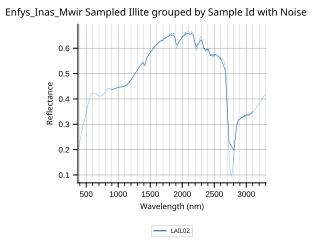

In [42]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True, ci=True)

**Figure 11** Mean of Noisy resampled example spectrum for Illite, showing mean and standard deviation of 100 repeat samples according to the spectral signal-to-noise ratio illustrated in figure 3.B.

Here we find that the standard deviation is almost negligible at the scale of the figure.

Plotting out all of the groups, we again see that the noise, at this scale, is indeed negligible for most entries. Here we opt to plot the complete range of noisy samples, rather than averaging and showing the (very small) standard deviation.

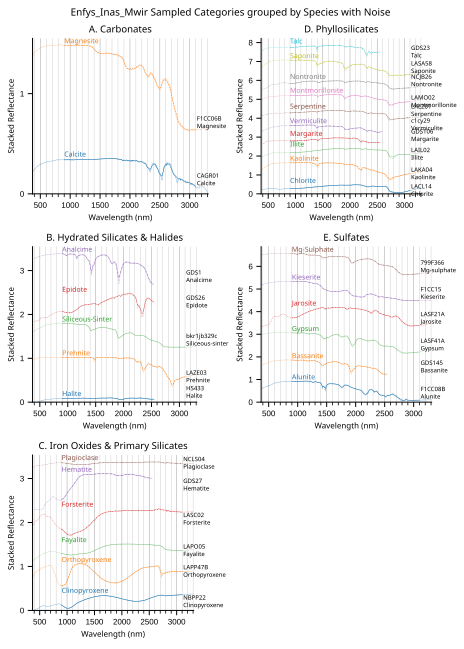

In [43]:
axes = obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=True, ci=False)

**Figure 12** The MICA files as sampled by *Enfys*, with repeat samples drawn according to the expected spectral Signal-to-Noise Ratio, with the original high-resolution spectra plotted underneath each.

The key conclusion to draw from the above figure is that expected noise for *Enfys* does not significantly intrude on the diagnostic features of these type specimen of minerals identified on the Mars surface.

We can illustrate this in greater deal by plotting each entry on a separate figure, with the y-axis clipped to the spectral range of entry. Note that for sample with a small spectral range (i.e. samples that are spectrally flat), this stretching will appear to amplify noise, so the y-axis range must be considered when assessing the noise.

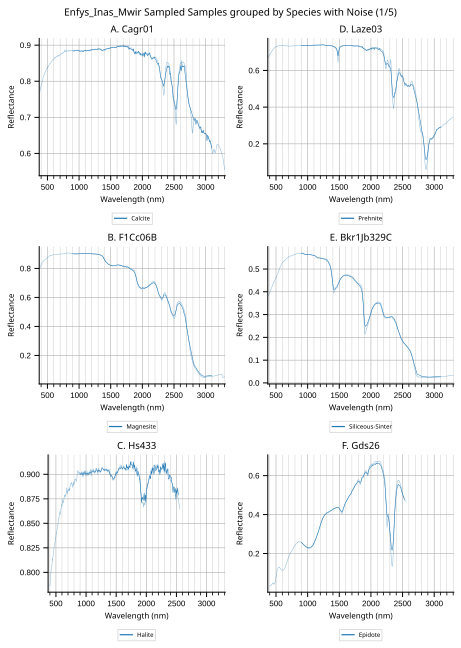

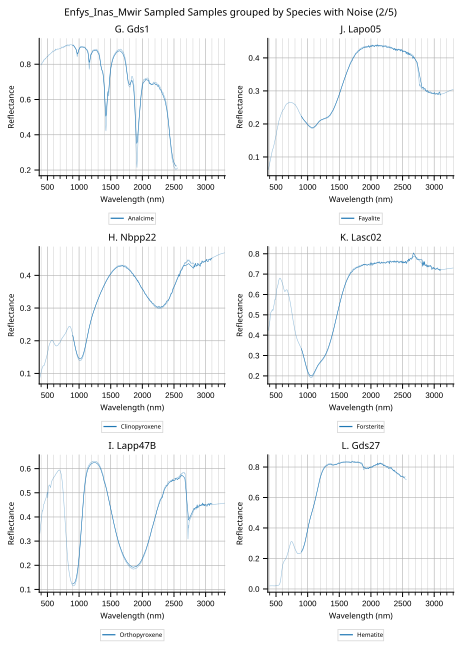

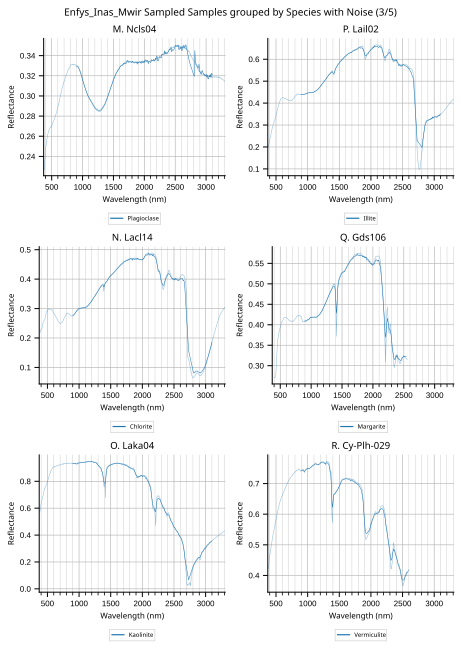

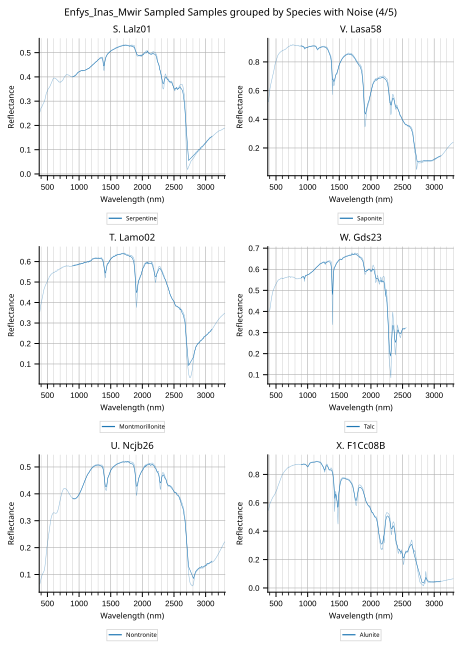

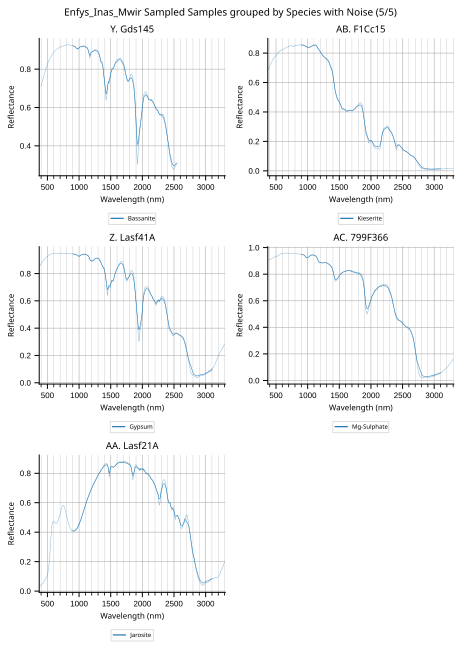

In [44]:
axes = obs.plot_profiles(scope='samples', groupby='Species', stacked=False, hires_under=True, ci=False)

**Figure 13** Detailled view of each entry in the spectral library, showing the scale of noise introduced, relative to the features of each spectrum, and the reflectance range.

We can export the dataset:

In [45]:
obs.export_main_df()

Exporting the Observation Pickle format...
Observation export complete.


## Continuum Removal

We can apply continuum removal, even to the noisy data.

In [46]:
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

cr_tool = sla(obs)
cr_obs = cr_tool.remove_continuum()

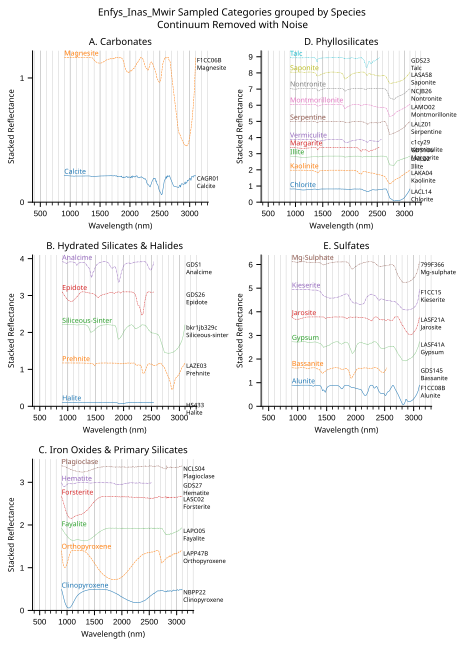

In [47]:
axes = cr_obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=False, ci=False)

**Figure 14** Continuum-Removed entries of the MICA Files, as sampled by *Enfys*, inclduing synthetic noise.

Again, we can export this:

In [48]:
cr_obs.export_main_df()

Exporting the Observation Pickle format...
Observation export complete.


## Waterfall Visualisation

For waterfall visualisations, we have the advantage of being able to visualise the noise introduced for each of multiple entries in 2D.

Each bar of the visualisation i scomposed of a series of rows, with each row as a redrawn noisy sample.

For this, we redraw with 128 repeat samples.

In [49]:
obs.add_noise(128, seed=0)

,Category,Root Data ID,Sample ID,Species,Subgroup,Group,Library,Sample Description,Date Added,Viewing Geometry,...,3011.83736494,3021.57325265,3031.3119922,3041.05356775,3050.79796359,3060.54516415,3070.29515395,3080.04791767,3089.80344009,3099.5617061
Data ID,,,,,,,,,,,,,,,,,,,,,
CAGR01 Calcite.,carbonates,CAGR01 Calcite,CAGR01,calcite,calcites,carbonates,MICA_new_dirtree,NaN,NaN,NaN,...,0.649349,0.643024,0.641201,0.646154,0.636673,0.625432,0.639902,0.624570,0.629260,0.620652
CAGR01 Calcite.1,carbonates,CAGR01 Calcite,CAGR01,calcite,calcites,carbonates,MICA_new_dirtree,NaN,NaN,NaN,...,0.647098,0.659418,0.651524,0.644076,0.650577,0.630123,0.637587,0.631154,0.616651,0.619038
CAGR01 Calcite.10,carbonates,CAGR01 Calcite,CAGR01,calcite,calcites,carbonates,MICA_new_dirtree,NaN,NaN,NaN,...,0.645598,0.650326,0.647778,0.644606,0.646832,0.636492,0.625464,0.629316,0.618005,0.621347
CAGR01 Calcite.100,carbonates,CAGR01 Calcite,CAGR01,calcite,calcites,carbonates,MICA_new_dirtree,NaN,NaN,NaN,...,0.658161,0.648469,0.652038,0.640378,0.638232,0.647711,0.626931,0.620040,0.621232,0.614327
CAGR01 Calcite.101,carbonates,CAGR01 Calcite,CAGR01,calcite,calcites,carbonates,MICA_new_dirtree,NaN,NaN,NaN,...,0.658691,0.647270,0.650712,0.649433,0.642791,0.640031,0.629831,0.637447,0.622535,0.614126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799F366 Mg-sulphate.95,sulfates,799F366 Mg-sulphate,799F366,mg-sulphate,hydrous_sulphates,sulphates,MICA_new_dirtree,NaN,NaN,NaN,...,0.043433,0.045057,0.045735,0.048127,0.049121,0.050753,0.052551,0.054074,0.056504,0.059817
799F366 Mg-sulphate.96,sulfates,799F366 Mg-sulphate,799F366,mg-sulphate,hydrous_sulphates,sulphates,MICA_new_dirtree,NaN,NaN,NaN,...,0.043580,0.045413,0.046499,0.047751,0.049622,0.051633,0.052128,0.054879,0.055670,0.059185
799F366 Mg-sulphate.97,sulfates,799F366 Mg-sulphate,799F366,mg-sulphate,hydrous_sulphates,sulphates,MICA_new_dirtree,NaN,NaN,NaN,...,0.043165,0.045067,0.046107,0.048149,0.049473,0.051247,0.052469,0.054169,0.056807,0.058655


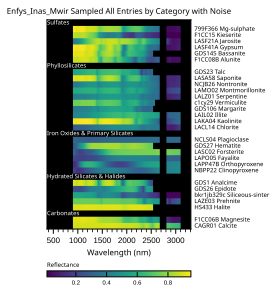

In [50]:
axes = obs.plot_profiles(scope='all', groupby='Category', stacked=False, waterfall=True, ci=False)

**Figure 15** Waterfall diagram of the entries of the MICA Files, as sampled by *Enfys*, including synthetic noise. Each entry bar is composed of *n* repeat noisy samples, such that each bar is composed of *n* rows, illustrating the noise.

We need to recompute the continuum-removed data on this noisy set.

In [51]:
cr_tool = sla(obs)
cr_obs = cr_tool.remove_continuum()

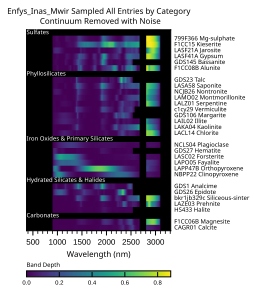

In [52]:
axes = cr_obs.plot_profiles(scope='all', groupby='Category', stacked=False, waterfall=True, ci=False)

**Figure 16** Continuum-Removed waterfall diagram of the entries of the MICA Files, as sampled by *Enfys*, including synthetic noise. Each entry bar is composed of *n* repeat noisy samples, such that each bar is composed of *n* rows, illustrating the noise.

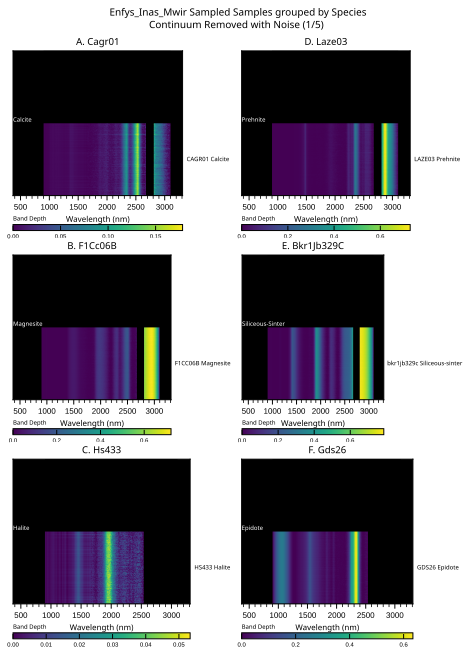

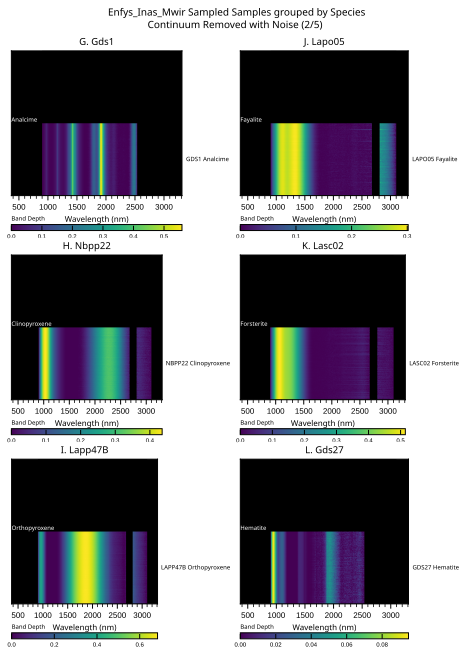

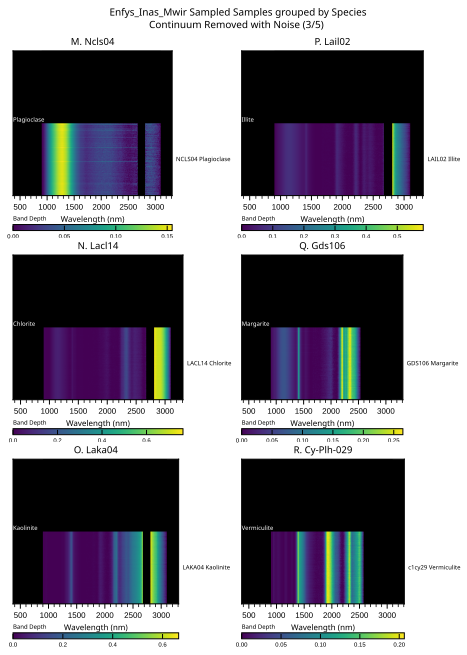

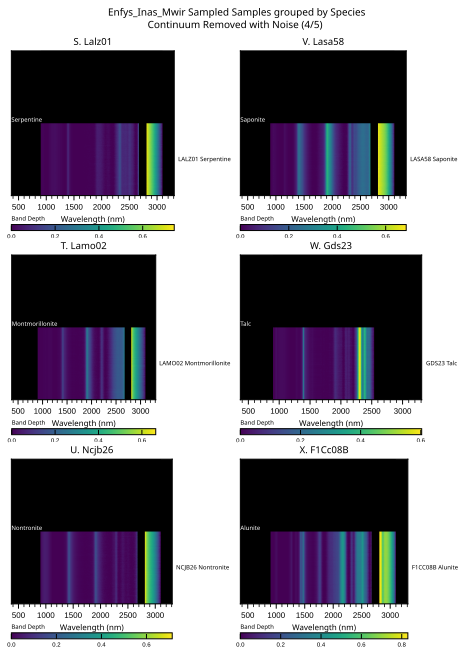

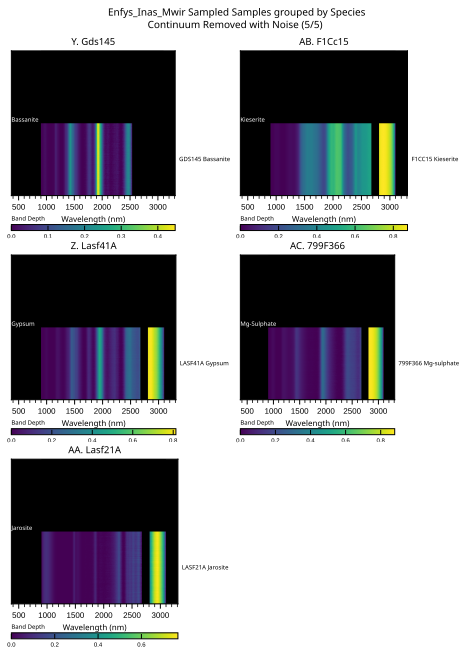

In [53]:
axes = cr_obs.plot_profiles(scope='samples', groupby='Species', stacked=False, waterfall=True, ci=False)

**Figure 17** Detailed waterfall view of each entry in the spectral library, showing the scale of noise introduced, relative to the features of each spectrum, and the reflectance range. Each entry bar is composed of *n* repeat noisy samples, such that each bar is composed of *n* rows, illustrating the noise.

### Validating the Noise

We can check that our noise is correct by aggregating the repeat samples to give the mean and standard deviation for each entry and each spectral channel (wavelength).

We can then compare this to the spectral SNR.

In [59]:
signal = obs.main_df.groupby('Root Data ID').mean()
noise = obs.main_df.groupby('Root Data ID').std()
snr = signal/noise

/var/folders/w4/44k32f413dd82lxmtw9456w80000gp/T/ipykernel_59533/2651352844.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  signal = obs.main_df.groupby('Root Data ID').mean()
/var/folders/w4/44k32f413dd82lxmtw9456w80000gp/T/ipykernel_59533/2651352844.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  noise = obs.main_df.groupby('Root Data ID').std()


In [90]:
snr.mean()

900.000000     18995.653023
903.285743     19300.937699
906.618278     19041.784707
909.999291     19439.110070
913.430570     19257.049290
                   ...     
3060.545164      125.671979
3070.295154      125.862409
3080.047918      124.439560
3089.803440      124.231021
3099.561706      121.513021
Length: 299, dtype: float64

Text(0, 0.5, 'SNR')

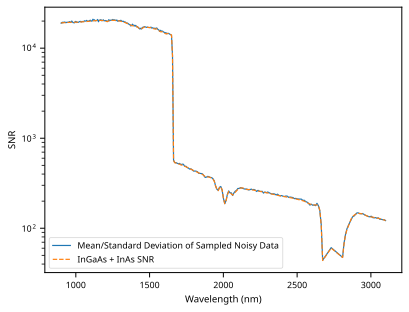

In [103]:
# plot the SNR
import seaborn as sns
# plot with log scale y axis
g = sns.lineplot(data=snr.mean(), label='Mean/Standard Deviation of Sampled Noisy Data', markers=True)
g.set(yscale="log")


# get instrument snr
sns.lineplot(data=obs.instrument.main_df, x='cwl', y='snr', label='InGaAs + InAs SNR', linestyle='--', markers=True)

g.set_xlabel('Wavelength (nm)')
g.set_ylabel('SNR')

## Spectral Angle Mapper

TODO: perform spectral angle mapper evaluation of each spectrum against the other spectra of the set.

# Discussion

Notes on what we found above, perhaps with some more analysis.

# Conclusions

Concluding remarks and summary of findings.

# References